In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile

zip_path = '/content/drive/MyDrive/GTSRBDataset/dataset.zip'
extract_path = '/content/GTSRB'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset unzipped successfully!")

Dataset unzipped successfully!


In [ ]:
# --- 1. SETUP AND INITIALIZATION ---

# Core libraries
import os
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Scikit-learn for data splitting and metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# TensorFlow and Keras for deep learning
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
                                     BatchNormalization, Activation, Add, GlobalAveragePooling2D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# --- CONFIGURATION ---
DATA_PATH='/content/GTSRB'
IMG_HEIGHT = 32
IMG_WIDTH = 32
NUM_CLASSES = 43
EPOCHS = 20 # Using a moderate number for demonstration; can be increased for better accuracy
BATCH_SIZE = 64

print("Setup Complete. TensorFlow version:", tf.__version__)

Setup Complete. TensorFlow version: 2.20.0


In [ ]:
# --- 2. DATA LOADING AND PREPROCESSING ---

def load_data(data_dir):
    """Loads images and labels from the GTSRB dataset structure."""
    images = []
    labels = []
    for class_id in range(NUM_CLASSES):
        class_path = os.path.join(data_dir, 'Train', str(class_id))
        if not os.path.isdir(class_path):
            continue
        for img_name in os.listdir(class_path):
            try:
                img_path = os.path.join(class_path, img_name)
                image = Image.open(img_path).resize((IMG_WIDTH, IMG_HEIGHT))
                images.append(np.array(image))
                labels.append(class_id)
            except Exception as e:
                print(f"Error loading image {img_path}: {e}")
    return np.array(images), np.array(labels)

# Load training data
X_train, y_train = load_data(DATA_PATH)
print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")

# Load test data
test_df = pd.read_csv(os.path.join(DATA_PATH, 'Test.csv'))
X_test = []
y_test = []
for img_path, class_id in zip(test_df['Path'], test_df['ClassId']):
    full_path = os.path.join(DATA_PATH, img_path)
    image = Image.open(full_path).resize((IMG_WIDTH, IMG_HEIGHT))
    X_test.append(np.array(image))
    y_test.append(class_id)

X_test = np.array(X_test)
y_test = np.array(y_test)
print(f"Test data shape: X={X_test.shape}, y={y_test.shape}")

# Normalize images to the range [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# One-hot encode the labels
y_train = to_categorical(y_train, NUM_CLASSES)
y_test_categorical = to_categorical(y_test, NUM_CLASSES)

# Create a validation set from the training data
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print("\nData preprocessing complete.")
print(f"Train images shape: {X_train.shape}")
print(f"Train labels shape: {y_train.shape}")
print(f"Validation images shape: {X_val.shape}")
print(f"Validation labels shape: {y_val.shape}")
print(f"Test images shape: {X_test.shape}")
print(f"Test labels shape: {y_test_categorical.shape}")


Training data shape: X=(39209, 32, 32, 3), y=(39209,)
Test data shape: X=(12630, 32, 32, 3), y=(12630,)

Data preprocessing complete.
Train images shape: (31367, 32, 32, 3)
Train labels shape: (31367, 43)
Validation images shape: (7842, 32, 32, 3)
Validation labels shape: (7842, 43)
Test images shape: (12630, 32, 32, 3)
Test labels shape: (12630, 43)


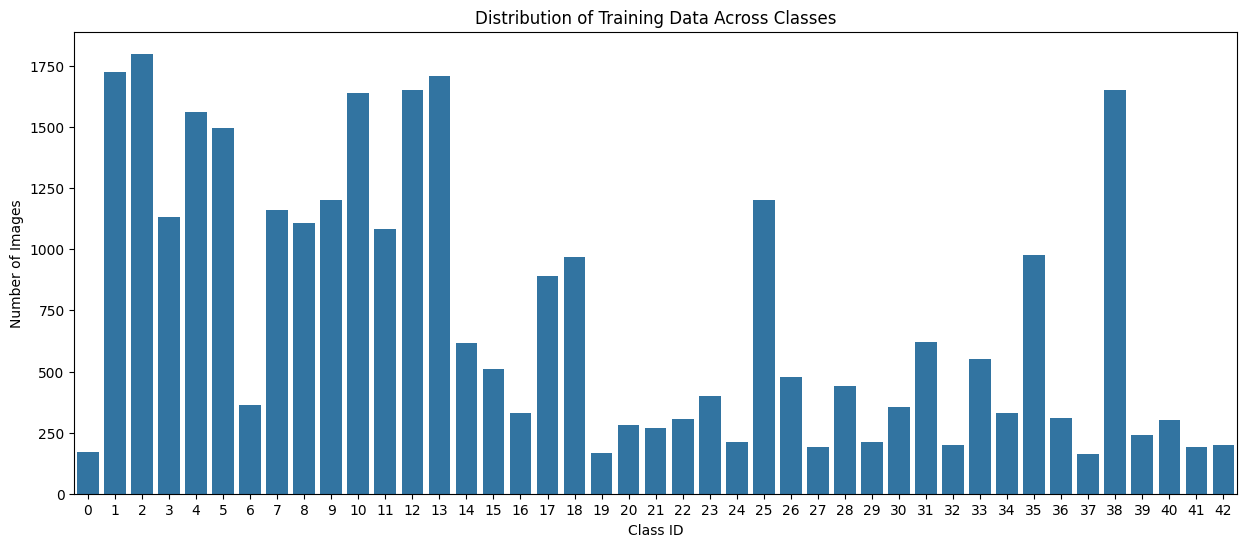

In [ ]:
# Visualize class distribution
plt.figure(figsize=(15, 6))
sns.countplot(x=np.argmax(y_train, axis=1))      #conversion of hot-encoding
plt.title('Distribution of Training Data Across Classes')
plt.xlabel('Class ID')
plt.ylabel('Number of Images')
plt.show()

In [ ]:
# --- 3. DATA AUGMENTATION SETUP ---

# 1. Without augmentation (only rescaling is inherent in our manual preprocessing)
datagen_no_aug = ImageDataGenerator()

# 2. With rotation augmentation
datagen_with_aug = ImageDataGenerator(
    rotation_range=15,       # Randomly rotate images by up to 15 degrees
    zoom_range=0.1,          # Randomly zoom in
    width_shift_range=0.1,   # Randomly shift images horizontally
    height_shift_range=0.1,  # Randomly shift images vertically
    shear_range=0.1,         # Shear transformations
    fill_mode='nearest'
)

# Fit the generator on the training data (important for some augmentations)
datagen_with_aug.fit(X_train)

In [ ]:
#function for training with and without augmentation

def train_and_evaluate(model, model_name, with_augmentation=False):
    print(f"\n--- Training {model_name} {'with' if with_augmentation else 'without'} Augmentation ---")

    # Callbacks for robust training
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)

    if with_augmentation:
        history = model.fit(
            datagen_with_aug.flow(X_train, y_train, batch_size=BATCH_SIZE),
            epochs=EPOCHS,
            validation_data=(X_val, y_val),
            callbacks=[early_stopping, reduce_lr],
            verbose=1
        )
    else:
        history = model.fit(
            X_train, y_train,
            batch_size=BATCH_SIZE,
            epochs=EPOCHS,
            validation_data=(X_val, y_val),
            callbacks=[early_stopping, reduce_lr],
            verbose=1
        )
    # Plotting training history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.legend()
    plt.show()

    # Evaluate on test set
    loss, accuracy = model.evaluate(X_test, y_test_categorical, verbose=0)
    print(f"Test Accuracy for {model_name}: {accuracy * 100:.2f}%")

    return model, history, accuracy

# Dictionary to store results
results = {}
trained_models = {}


--- Training SimpleCNN_NoAug without Augmentation ---
Epoch 1/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 102s 202ms/step - accuracy: 0.5196 - loss: 1.6725 - val_accuracy: 0.8772 - val_loss: 0.4318 - learning_rate: 0.0010
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 96s 195ms/step - accuracy: 0.9064 - loss: 0.3054 - val_accuracy: 0.9546 - val_loss: 0.1497 - learning_rate: 0.0010
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 139s 188ms/step - accuracy: 0.9639 - loss: 0.1191 - val_accuracy: 0.9870 - val_loss: 0.0609 - learning_rate: 0.0010
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 95s 193ms/step - accuracy: 0.9795 - loss: 0.0710 - val_accuracy: 0.9881 - val_loss: 0.0506 - learning_rate: 0.0010
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 94s 191ms/step - accuracy: 0.9834 - loss: 0.0551 - val_accuracy: 0.9921 - val_loss: 0.0397 - learning_rate: 0.0010
Epoch 6/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 147s 202ms/step - accuracy: 0.9874 - loss: 0.0418 - val_accuracy: 0.9927 - val_loss: 0.0376 - learning_rate: 0.0010
Epoch 7/20
4

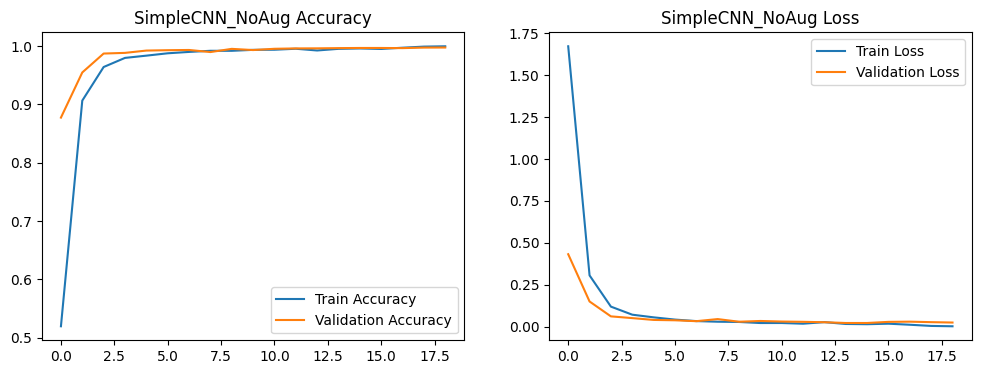

Test Accuracy for SimpleCNN_NoAug: 95.22%

--- Training SimpleCNN_WithAug with Augmentation ---
Epoch 1/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 121s 242ms/step - accuracy: 0.3276 - loss: 2.3028 - val_accuracy: 0.6006 - val_loss: 1.2376 - learning_rate: 0.0010
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 118s 239ms/step - accuracy: 0.6471 - loss: 1.0713 - val_accuracy: 0.8448 - val_loss: 0.5210 - learning_rate: 0.0010
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 122s 248ms/step - accuracy: 0.8095 - loss: 0.5755 - val_accuracy: 0.9144 - val_loss: 0.2723 - learning_rate: 0.0010
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 118s 240ms/step - accuracy: 0.8818 - loss: 0.3586 - val_accuracy: 0.9654 - val_loss: 0.1141 - learning_rate: 0.0010
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 119s 242ms/step - accuracy: 0.9142 - loss: 0.2624 - val_accuracy: 0.9697 - val_loss: 0.1051 - learning_rate: 0.0010
Epoch 6/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 118s 239ms/step - accuracy: 0.9352 - loss: 0.1994 - val_accuracy: 0.9816 - val_loss:

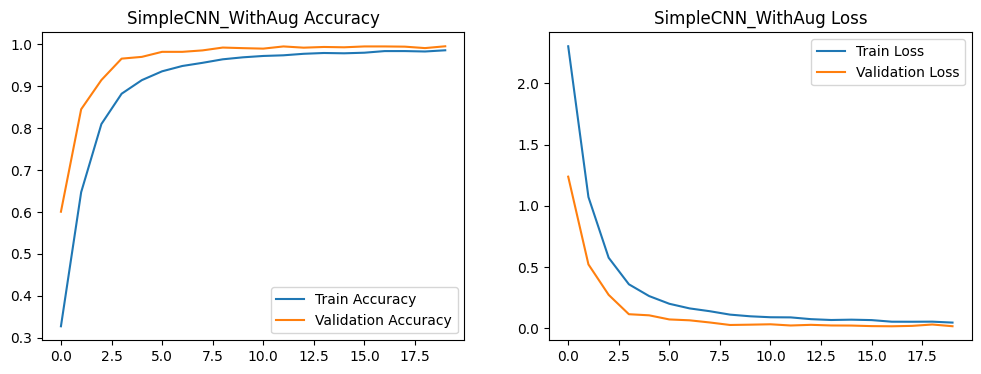

Test Accuracy for SimpleCNN_WithAug: 94.14%


In [ ]:
# --- Architecture 1: Simple CNN ---

def build_simple_cnn():
    model = Sequential([
        Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

        # Conv -> Activation -> Pooling
        Conv2D(32, (3, 3), padding='same', activation='relu'),
        MaxPooling2D((2, 2)),

        # Conv -> Activation -> Pooling
        Conv2D(64, (3, 3), padding='same', activation='relu'),
        MaxPooling2D((2, 2)),

        # Conv -> Activation -> Pooling
        Conv2D(128, (3, 3), padding='same', activation='relu'),
        MaxPooling2D((2, 2)),

        # Classifier
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ], name="SimpleCNN")

    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# --- Train Simple CNN WITHOUT Augmentation ---
simple_cnn_no_aug = build_simple_cnn()
model_no_aug, _, acc_no_aug = train_and_evaluate(simple_cnn_no_aug, "SimpleCNN_NoAug", False)
results['SimpleCNN_NoAug'] = acc_no_aug

# --- Train Simple CNN WITH Augmentation ---
simple_cnn_with_aug = build_simple_cnn()
model_with_aug, _, acc_with_aug = train_and_evaluate(simple_cnn_with_aug, "SimpleCNN_WithAug", True)
results['SimpleCNN_WithAug'] = acc_with_aug
trained_models['SimpleCNN'] = model_with_aug


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


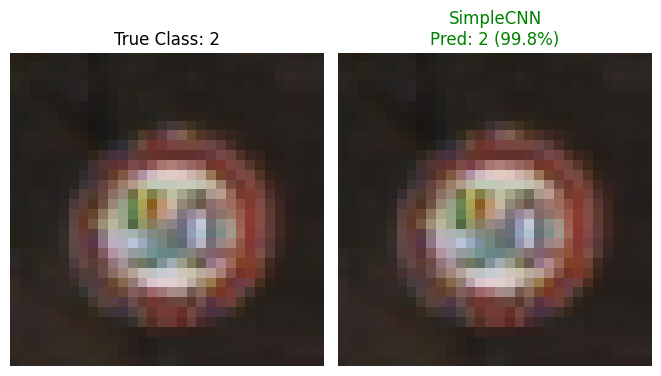

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


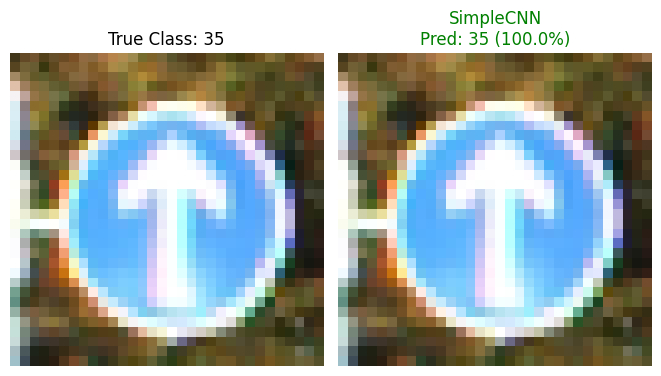

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


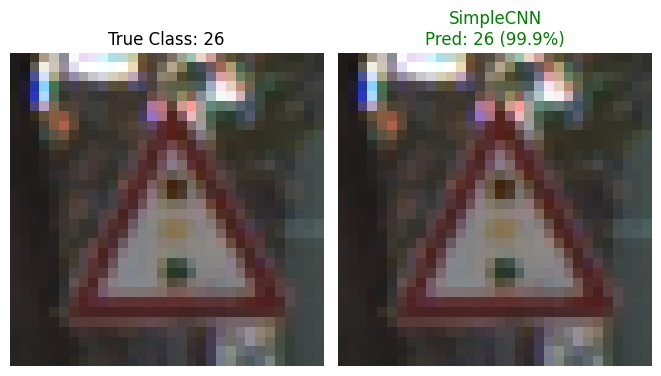

In [ ]:
#final testing and prediction

def predict_and_visualize_random_test_image(models_dict, X_test, y_test, num_samples=1):
    """
    Selects random images from the test set, predicts their classes using the trained models,
    and displays the images with their true and predicted labels.
    """
    for _ in range(num_samples):
        # 1. Pick a random index from the test set
        idx = random.randint(0, len(X_test) - 1)
        sample_image = X_test[idx]
        true_label = y_test[idx]  # This is the original integer class ID

        # Reshape the image to add the batch dimension: (1, 32, 32, 3)
        input_image = np.expand_dims(sample_image, axis=0)

        # 2. Set up the plotting
        plt.figure(figsize=(10, 4))

        # Display the actual image
        plt.subplot(1, 3, 1)
        plt.imshow(sample_image)
        plt.title(f"True Class: {true_label}")
        plt.axis('off')

        # 3. Generate predictions for each model in your dictionary
        plot_idx = 2
        for model_name, model in models_dict.items():
            # Get the probability distribution
            preds = model.predict(input_image)
            # Find the class with the highest probability
            predicted_class = np.argmax(preds)
            confidence = preds[0, predicted_class] * 100

            # Plot placeholder for prediction text/confidence if desired,
            # or simply display it in the title
            plt.subplot(1, 3, plot_idx)
            plt.imshow(sample_image)

            # Highlight correct predictions in green, incorrect in red
            color = 'green' if predicted_class == true_label else 'red'

            plt.title(f"{model_name}\nPred: {predicted_class} ({confidence:.1f}%)", color=color)
            plt.axis('off')
            plot_idx += 1

        plt.tight_layout()
        plt.show()

# Run the evaluation function using your saved models and original integer labels (y_test)
predict_and_visualize_random_test_image(trained_models, X_test, y_test, num_samples=3)